In [ ]:
# Cell 1 — Reinstall libraries and reload data
!pip install datasets transformers torch rouge-score nltk spacy scikit-learn -q
!python -m spacy download en_core_web_sm -q

import pandas as pd
import nltk
import spacy
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from nltk.tokenize import word_tokenize
from datasets import load_dataset
import re
import warnings
warnings.filterwarnings('ignore')

nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)

print("Libraries loaded")
print("Downloading CNN/DailyMail dataset...")

dataset = load_dataset("cnn_dailymail", "3.0.0")

print(f"Dataset loaded — {len(dataset['train'])} training articles")
print("Preprocessing 5000 articles...")

nlp = spacy.load('en_core_web_sm')
stop_words = set(stopwords.words('english'))
stemmer = PorterStemmer()

def full_preprocess(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    tokens = word_tokenize(text)
    tokens = [t for t in tokens if t not in stop_words]
    tokens_stemmed = [stemmer.stem(t) for t in tokens]
    doc = nlp(' '.join(tokens[:100]))
    tokens_lemmatized = [token.lemma_ for token in doc]
    return {
        'preprocessed': ' '.join(tokens),
        'stemmed': ' '.join(tokens_stemmed),
        'lemmatized': ' '.join(tokens_lemmatized)
    }

sample_data = dataset["train"].select(range(5000))
articles, highlights, preprocessed, stemmed, lemmatized, art_wc, hl_wc = [], [], [], [], [], [], []

for i, item in enumerate(sample_data):
    if i % 1000 == 0:
        print(f"  Processing {i}/5000...")
    result = full_preprocess(item["article"])
    articles.append(item["article"])
    highlights.append(item["highlights"])
    preprocessed.append(result['preprocessed'])
    stemmed.append(result['stemmed'])
    lemmatized.append(result['lemmatized'])
    art_wc.append(len(item["article"].split()))
    hl_wc.append(len(item["highlights"].split()))

df = pd.DataFrame({
    'article': articles,
    'highlights': highlights,
    'preprocessed': preprocessed,
    'stemmed': stemmed,
    'lemmatized': lemmatized,
    'article_word_count': art_wc,
    'highlights_word_count': hl_wc
})

df.to_csv('docsnap_fully_preprocessed.csv', index=False)
print(f"\nData ready — {len(df)} articles preprocessed and saved")
print(f"Average article length: {df['article_word_count'].mean():.0f} words")

  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 91.6 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.
Libraries loaded


README.md: 0.00B [00:00, ?B/s]

3.0.0/train-00000-of-00003.parquet:   0%|          | 0.00/257M [00:00<?, ?B/s]

3.0.0/train-00001-of-00003.parquet:   0%|          | 0.00/257M [00:00<?, ?B/s]

3.0.0/train-00002-of-00003.parquet:   0%|          | 0.00/259M [00:00<?, ?B/s]

...

3.0.0/test-00000-of-00001.parquet:   0%|          | 0.00/30.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/287113 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/13368 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/11490 [00:00<?, ? examples/s]

Dataset loaded — 287113 training articles
Preprocessing 5000 articles...
  Processing 0/5000...
  Processing 1000/5000...
  Processing 2000/5000...
  Processing 3000/5000...
  Processing 4000/5000...

Data ready — 5000 articles preprocessed and saved
Average article length: 615 words


=== WORD FREQUENCY ANALYSIS ===

Top 20 most frequent words:
Rank   Word                 Frequency 
------------------------------------
1      said                 31925     
2      cnn                  8403      
3      people               7476      
4      one                  7222      
5      us                   6237      
6      would                5714      
7      new                  5480      
8      also                 5301      
9      two                  4921      
10     time                 4365      
11     told                 4352      
12     years                4333      
13     like                 4143      
14     says                 4099      
15     president            3947      
16     police               3907      
17     first                3741      
18     last                 3543      
19     could                3523      
20     government           3450      


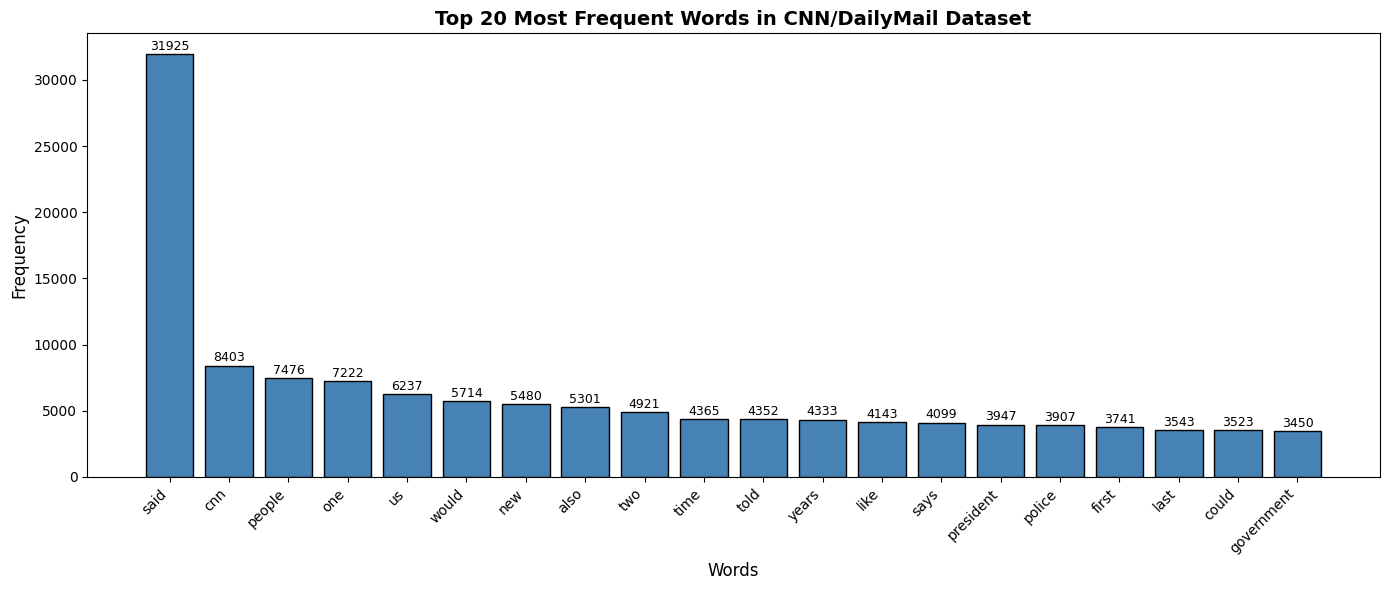


Total unique words in dataset: 67,659
Total tokens analyzed: 1,724,383
Chart saved as word_frequency.png


In [ ]:
# Cell 2 — Word Frequency Analysis
import matplotlib.pyplot as plt
from collections import Counter

print("=== WORD FREQUENCY ANALYSIS ===\n")

# Combine all preprocessed tokens
all_tokens = ' '.join(df['preprocessed'].tolist()).split()

# Count frequencies
word_freq = Counter(all_tokens)
most_common = word_freq.most_common(20)

print("Top 20 most frequent words:")
print(f"{'Rank':<6} {'Word':<20} {'Frequency':<10}")
print("-" * 36)
for i, (word, freq) in enumerate(most_common, 1):
    print(f"{i:<6} {word:<20} {freq:<10}")

# Plot bar chart
words = [w[0] for w in most_common]
freqs = [w[1] for w in most_common]

plt.figure(figsize=(14, 6))
bars = plt.bar(words, freqs, color='steelblue', edgecolor='black')
plt.title('Top 20 Most Frequent Words in CNN/DailyMail Dataset',
          fontsize=14, fontweight='bold')
plt.xlabel('Words', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.xticks(rotation=45, ha='right')

# Add value labels on bars
for bar, freq in zip(bars, freqs):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 100,
             str(freq), ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('word_frequency.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nTotal unique words in dataset: {len(word_freq):,}")
print(f"Total tokens analyzed: {len(all_tokens):,}")
print("Chart saved as word_frequency.png")

=== TF-IDF ANALYSIS ===

Top 20 words by TF-IDF score:
Rank   Word                 TF-IDF Score
--------------------------------------
1      said                 0.440162
2      people               0.138268
3      one                  0.135019
4      cnn                  0.130288
5      us                   0.127516
6      new                  0.123522
7      would                0.111036
8      also                 0.109196
9      two                  0.107012
10     years                0.098880
11     told                 0.097667
12     police               0.097452
13     time                 0.096506
14     president            0.096377
15     first                0.095419
16     like                 0.094534
17     says                 0.092982
18     government           0.091956
19     last                 0.088422
20     could                0.080925


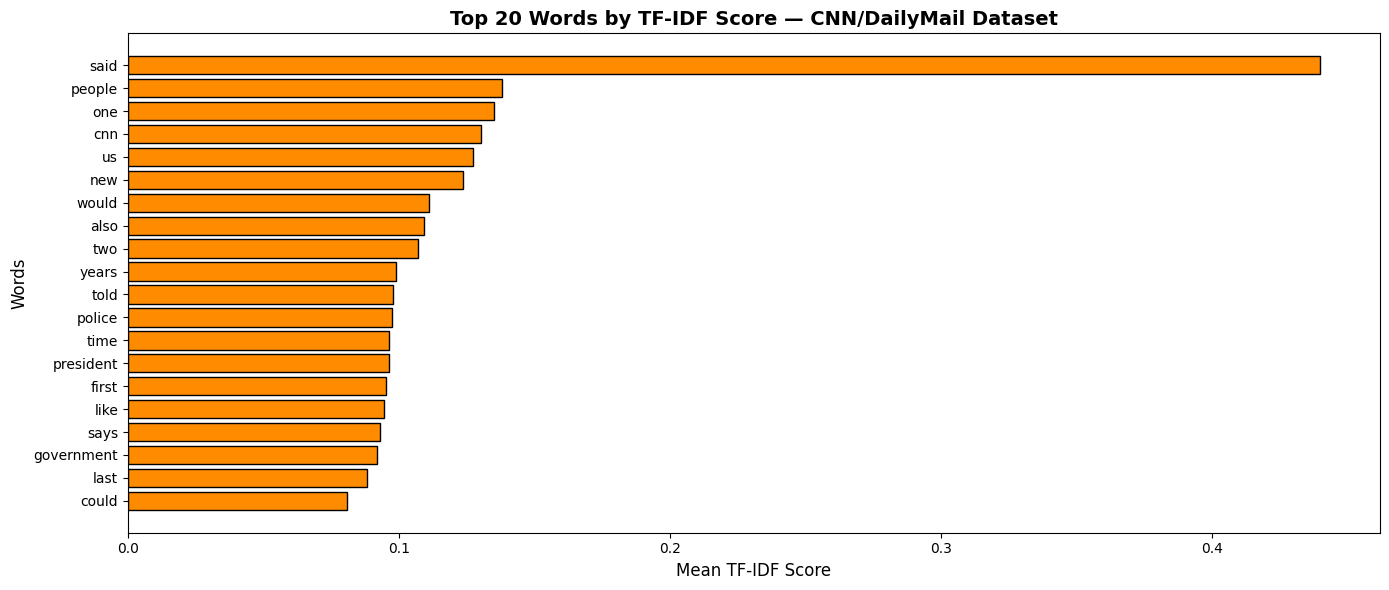


TF-IDF matrix shape: (5000, 20)
Documents analyzed: 5000
Features extracted: 20
Chart saved as tfidf_scores.png


In [ ]:
# Cell 3 — TF-IDF Analysis
from sklearn.feature_extraction.text import TfidfVectorizer
import numpy as np

print("=== TF-IDF ANALYSIS ===\n")

# Apply TF-IDF on preprocessed articles
vectorizer = TfidfVectorizer(max_features=20, max_df=0.95, min_df=5)
tfidf_matrix = vectorizer.fit_transform(df['preprocessed'])

# Get feature names and scores
feature_names = vectorizer.get_feature_names_out()
mean_tfidf = np.mean(tfidf_matrix.toarray(), axis=0)

# Sort by score
tfidf_scores = sorted(zip(feature_names, mean_tfidf),
                       key=lambda x: x[1], reverse=True)

print("Top 20 words by TF-IDF score:")
print(f"{'Rank':<6} {'Word':<20} {'TF-IDF Score':<12}")
print("-" * 38)
for i, (word, score) in enumerate(tfidf_scores, 1):
    print(f"{i:<6} {word:<20} {score:.6f}")

# Plot
words_tfidf = [x[0] for x in tfidf_scores]
scores_tfidf = [x[1] for x in tfidf_scores]

plt.figure(figsize=(14, 6))
bars = plt.barh(words_tfidf[::-1], scores_tfidf[::-1], color='darkorange', edgecolor='black')
plt.title('Top 20 Words by TF-IDF Score — CNN/DailyMail Dataset',
          fontsize=14, fontweight='bold')
plt.xlabel('Mean TF-IDF Score', fontsize=12)
plt.ylabel('Words', fontsize=12)
plt.tight_layout()
plt.savefig('tfidf_scores.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nTF-IDF matrix shape: {tfidf_matrix.shape}")
print(f"Documents analyzed: {tfidf_matrix.shape[0]}")
print(f"Features extracted: {tfidf_matrix.shape[1]}")
print("Chart saved as tfidf_scores.png")

=== NAMED ENTITY RECOGNITION (NER) ===

Running NER on 500 articles...
  Processing article 0/500...
  Processing article 100/500...
  Processing article 200/500...
  Processing article 300/500...
  Processing article 400/500...

Top 10 Entity Types found:
Rank   Entity Type          Count      Description
------------------------------------------------------------
1      GPE                  2466       Countries, cities, states
2      PERSON               2224       People, names
3      ORG                  2125       Organizations, companies
4      DATE                 1769       Dates, periods
5      CARDINAL             1031       Numbers
6      NORP                 764        Nationalities, groups
7      TIME                 246        Time expressions
8      ORDINAL              238        Other
9      LOC                  142        Locations
10     FAC                  115        Other


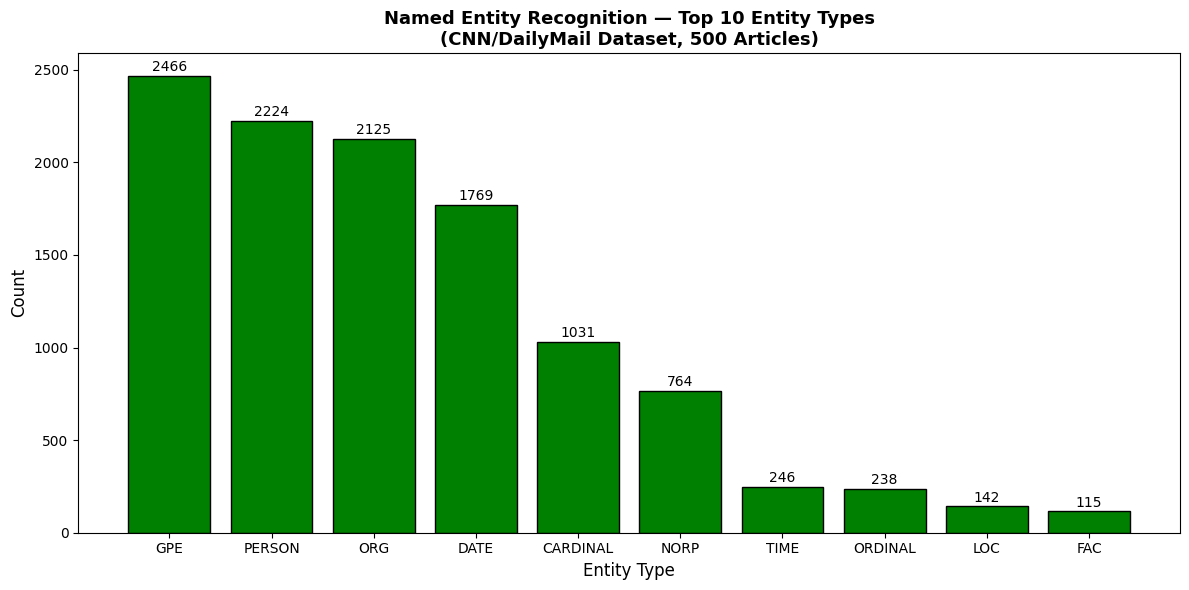


Sample entities found:
Entity                         Type           
---------------------------------------------
Strike Eagle                   PERSON         
JOHANNESBURG                   GPE            
Scott                          ORG            
Sudanese                       NORP           
Sacred Heart                   PERSON         
Phalange                       NORP           
Stephen McManus                PERSON         
the Marin County Sheriff's Department ORG            
Hawaii                         GPE            
campus more than eight years ago DATE           
Simi Valley                    GPE            
more than $1.7 million         MONEY          
15 days                        DATE           
Lions                          ORG            
September 30                   DATE           

Total entities found: 11,622
Unique entity types: 18
Chart saved as ner_analysis.png


In [ ]:
# Cell 4 — Named Entity Recognition (NER)
import spacy
from collections import Counter
import matplotlib.pyplot as plt

print("=== NAMED ENTITY RECOGNITION (NER) ===\n")

nlp = spacy.load('en_core_web_sm')

# Run NER on 500 articles (sample for speed)
print("Running NER on 500 articles...")

all_entities = []
entity_types = []

for i, article in enumerate(df['article'][:500]):
    if i % 100 == 0:
        print(f"  Processing article {i}/500...")
    doc = nlp(article[:1000])  # first 1000 chars per article
    for ent in doc.ents:
        all_entities.append((ent.text, ent.label_))
        entity_types.append(ent.label_)

# Count entity types
type_counts = Counter(entity_types)
most_common_types = type_counts.most_common(10)

print("\nTop 10 Entity Types found:")
print(f"{'Rank':<6} {'Entity Type':<20} {'Count':<10} {'Description'}")
print("-" * 60)

entity_descriptions = {
    'PERSON': 'People, names',
    'ORG': 'Organizations, companies',
    'GPE': 'Countries, cities, states',
    'DATE': 'Dates, periods',
    'NORP': 'Nationalities, groups',
    'CARDINAL': 'Numbers',
    'LOC': 'Locations',
    'MONEY': 'Money amounts',
    'TIME': 'Time expressions',
    'PERCENT': 'Percentages'
}

for i, (etype, count) in enumerate(most_common_types, 1):
    desc = entity_descriptions.get(etype, 'Other')
    print(f"{i:<6} {etype:<20} {count:<10} {desc}")

# Plot
types = [x[0] for x in most_common_types]
counts = [x[1] for x in most_common_types]

plt.figure(figsize=(12, 6))
bars = plt.bar(types, counts, color='green', edgecolor='black')
plt.title('Named Entity Recognition — Top 10 Entity Types\n(CNN/DailyMail Dataset, 500 Articles)',
          fontsize=13, fontweight='bold')
plt.xlabel('Entity Type', fontsize=12)
plt.ylabel('Count', fontsize=12)

for bar, count in zip(bars, counts):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 10,
             str(count), ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.savefig('ner_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

# Show sample entities
print(f"\nSample entities found:")
print(f"{'Entity':<30} {'Type':<15}")
print("-" * 45)
for ent, label in list(set(all_entities))[:15]:
    print(f"{ent:<30} {label:<15}")

print(f"\nTotal entities found: {len(all_entities):,}")
print(f"Unique entity types: {len(type_counts)}")
print("Chart saved as ner_analysis.png")

=== DOCUMENT LENGTH DISTRIBUTION ===

Article Length Statistics:
  Minimum  : 18 words
  Maximum  : 1831 words
  Mean     : 615 words
  Median   : 570 words
  Std Dev  : 302 words

Summary Length Statistics:
  Minimum  : 11 words
  Maximum  : 75 words
  Mean     : 44 words
  Median   : 45 words
  Std Dev  : 8 words

Average compression ratio: 14.0x
(Articles are on average 14.0x longer than summaries)


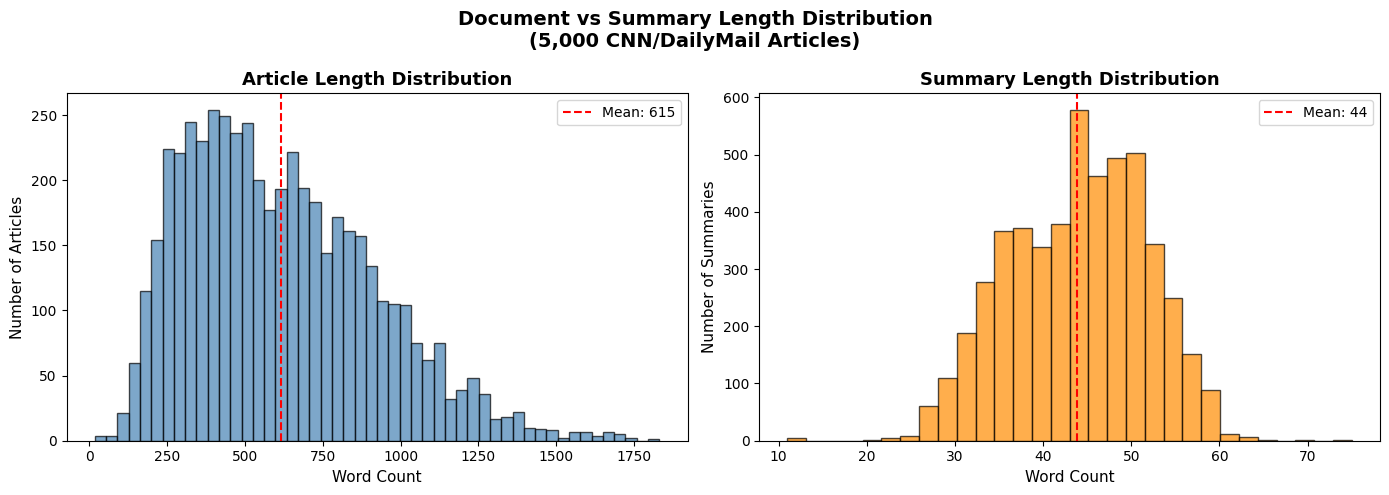


Chart saved as length_distribution.png


In [ ]:
# Cell 5 — Document Length Distribution
import matplotlib.pyplot as plt
import numpy as np

print("=== DOCUMENT LENGTH DISTRIBUTION ===\n")

article_lengths = df['article_word_count']
summary_lengths = df['highlights_word_count']

# Statistics
print("Article Length Statistics:")
print(f"  Minimum  : {article_lengths.min()} words")
print(f"  Maximum  : {article_lengths.max()} words")
print(f"  Mean     : {article_lengths.mean():.0f} words")
print(f"  Median   : {article_lengths.median():.0f} words")
print(f"  Std Dev  : {article_lengths.std():.0f} words")

print("\nSummary Length Statistics:")
print(f"  Minimum  : {summary_lengths.min()} words")
print(f"  Maximum  : {summary_lengths.max()} words")
print(f"  Mean     : {summary_lengths.mean():.0f} words")
print(f"  Median   : {summary_lengths.median():.0f} words")
print(f"  Std Dev  : {summary_lengths.std():.0f} words")

compression_ratio = article_lengths.mean() / summary_lengths.mean()
print(f"\nAverage compression ratio: {compression_ratio:.1f}x")
print(f"(Articles are on average {compression_ratio:.1f}x longer than summaries)")

# Plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.hist(article_lengths, bins=50, color='steelblue',
         edgecolor='black', alpha=0.7)
ax1.set_title('Article Length Distribution', fontsize=13, fontweight='bold')
ax1.set_xlabel('Word Count', fontsize=11)
ax1.set_ylabel('Number of Articles', fontsize=11)
ax1.axvline(article_lengths.mean(), color='red',
            linestyle='--', label=f'Mean: {article_lengths.mean():.0f}')
ax1.legend()

ax2.hist(summary_lengths, bins=30, color='darkorange',
         edgecolor='black', alpha=0.7)
ax2.set_title('Summary Length Distribution', fontsize=13, fontweight='bold')
ax2.set_xlabel('Word Count', fontsize=11)
ax2.set_ylabel('Number of Summaries', fontsize=11)
ax2.axvline(summary_lengths.mean(), color='red',
            linestyle='--', label=f'Mean: {summary_lengths.mean():.0f}')
ax2.legend()

plt.suptitle('Document vs Summary Length Distribution\n(5,000 CNN/DailyMail Articles)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('length_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nChart saved as length_distribution.png")

In [ ]:
# Cell 6 — Save all EDA outputs summary
print("=== EDA COMPLETE — FILES SAVED ===")
print("word_frequency.png     — Word frequency bar chart")
print("tfidf_scores.png       — TF-IDF horizontal bar chart")
print("ner_analysis.png       — NER entity type chart")
print("length_distribution.png — Article vs summary length")
print("\nAll 4 charts generated from real CNN/DailyMail data")
print("5000 articles analyzed")
print("EDA Week 3-4 complete")

=== EDA COMPLETE — FILES SAVED ===
word_frequency.png     — Word frequency bar chart
tfidf_scores.png       — TF-IDF horizontal bar chart
ner_analysis.png       — NER entity type chart
length_distribution.png — Article vs summary length

All 4 charts generated from real CNN/DailyMail data
5000 articles analyzed
EDA Week 3-4 complete


In [ ]:
from google.colab import drive
drive.mount('/content/drive')
print("Drive mounted")

Mounted at /content/drive
Drive mounted


In [ ]:
# Cell 7 — Load ArXiv data from Drive
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
from sklearn.feature_extraction.text import TfidfVectorizer
import numpy as np
import spacy
import warnings
warnings.filterwarnings('ignore')

arxiv_df = pd.read_csv('/content/drive/MyDrive/DocSnap_Project/arxiv_preprocessed.csv')
nlp = spacy.load('en_core_web_sm')

print(f"ArXiv data loaded: {len(arxiv_df)} papers")
print(f"Columns: {list(arxiv_df.columns)}")
print(f"Average paper length: {arxiv_df['article_word_count'].mean():.0f} words")
print(f"Average summary length: {arxiv_df['summary_word_count'].mean():.0f} words")

ArXiv data loaded: 2000 papers
Columns: ['article', 'summary', 'preprocessed', 'stemmed', 'lemmatized', 'article_word_count', 'summary_word_count']
Average paper length: 5894 words
Average summary length: 283 words


=== ARXIV EDA — ALL THREE TASKS ===

TASK 1: WORD FREQUENCY ANALYSIS
Rank   Word                 Frequency 
------------------------------------
1      xmath                13128     
2      xcite                9032      
3      one                  1681      
4      two                  1310      
5      model                1304      
6      energy               1293      
7      et                   1270      
8      al                   1237      
9      quantum              1191      
10     field                1138      
11     also                 1118      
12     time                 1050      
13     mass                 1031      
14     systems              973       
15     eg                   947       
16     system               894       
17     high                 816       
18     models               811       
19     large                804       
20     state                784       

Total unique words: 23,553
Total tokens: 352,974


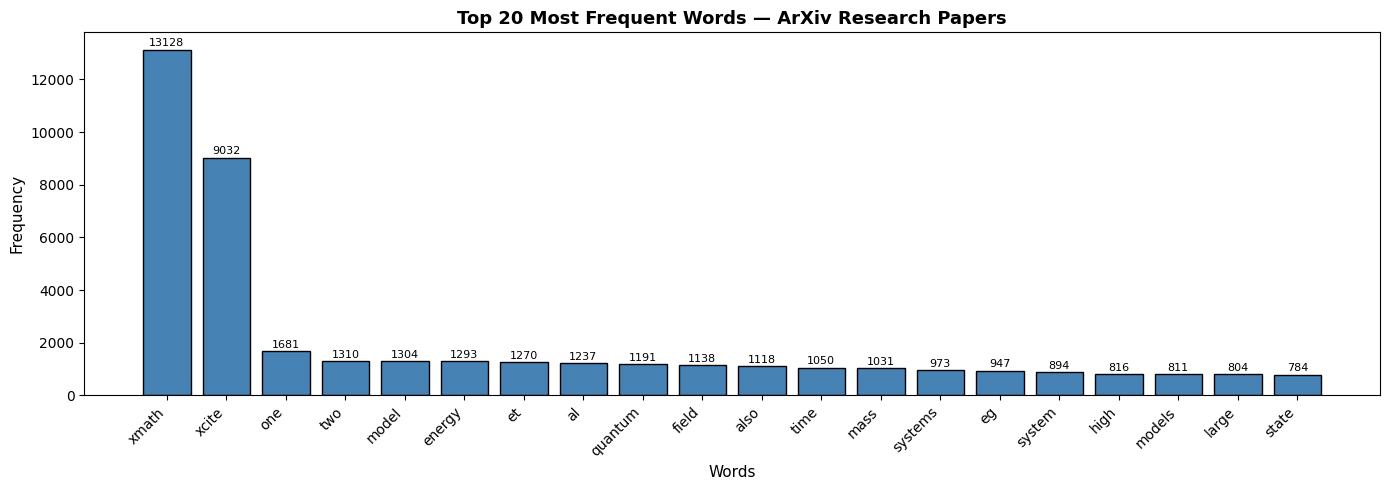

Chart saved: arxiv_word_frequency.png

TASK 2: TF-IDF ANALYSIS
Rank   Word                 TF-IDF Score
--------------------------------------
1      xmath                0.382329
2      xcite                0.341336
3      one                  0.090578
4      energy               0.086537
5      model                0.082865
6      field                0.077436
7      two                  0.076548
8      quantum              0.075607
9      mass                 0.072493
10     et                   0.071713
11     time                 0.071049
12     al                   0.070176
13     systems              0.069062
14     also                 0.068349
15     eg                   0.068251
16     high                 0.064152
17     system               0.063288
18     large                0.060281
19     models               0.058727
20     state                0.054063

Documents analyzed: 2000
Features extracted: 20


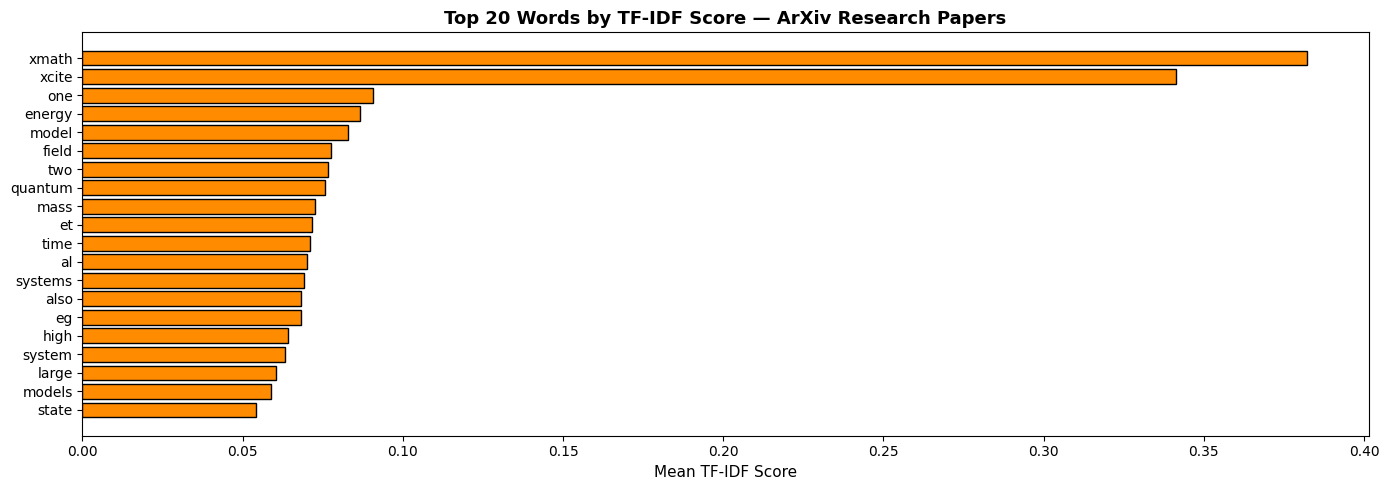

Chart saved: arxiv_tfidf_scores.png

TASK 3: NAMED ENTITY RECOGNITION (NER)
Running NER on 200 ArXiv papers...
  Processing paper 0/200...
  Processing paper 50/200...
  Processing paper 100/200...
  Processing paper 150/200...

Rank   Entity Type          Count      Description
-------------------------------------------------------
1      CARDINAL             296        Numbers
2      DATE                 245        Dates, periods
3      ORG                  217        Organizations
4      PERSON               157        People, names
5      GPE                  54         Countries, cities
6      ORDINAL              43         Other
7      NORP                 27         Nationalities, groups
8      QUANTITY             8          Other
9      PRODUCT              6          Other
10     PERCENT              6          Percentages

Total entities found: 1,066
Unique entity types: 13


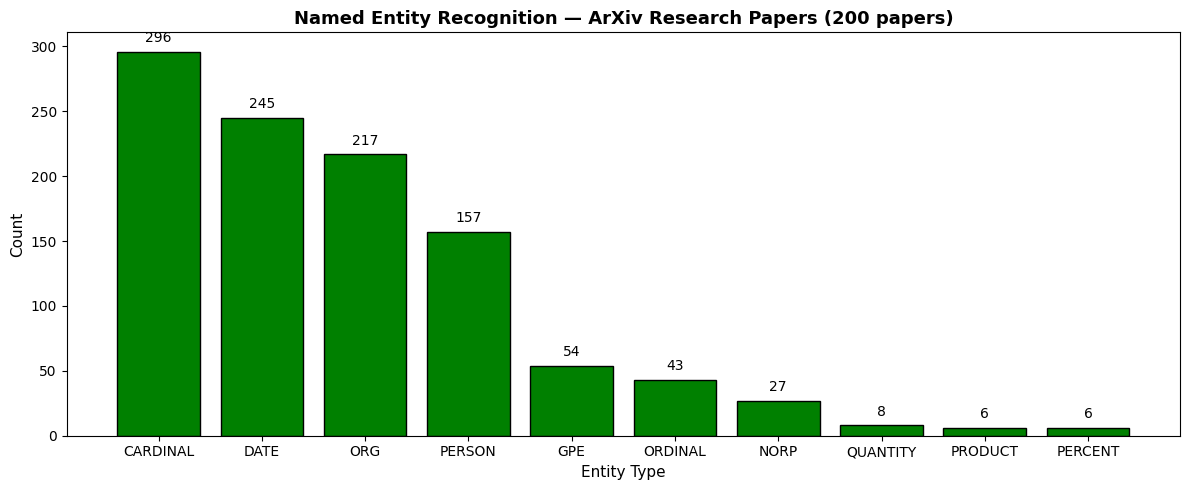

Chart saved: arxiv_ner_analysis.png

=== ARXIV EDA COMPLETE ===
All 3 tasks done on ArXiv research papers
3 charts saved


In [ ]:
# Cell 8 — ArXiv EDA (Word Frequency, TF-IDF, NER)
import nltk
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
from nltk.tokenize import sent_tokenize

print("=== ARXIV EDA — ALL THREE TASKS ===\n")

# ── TASK 1: Word Frequency ──
print("TASK 1: WORD FREQUENCY ANALYSIS")
all_tokens = ' '.join(arxiv_df['preprocessed'].dropna().tolist()).split()
word_freq = Counter(all_tokens)
most_common = word_freq.most_common(20)

print(f"{'Rank':<6} {'Word':<20} {'Frequency':<10}")
print("-" * 36)
for i, (word, freq) in enumerate(most_common, 1):
    print(f"{i:<6} {word:<20} {freq:<10}")

print(f"\nTotal unique words: {len(word_freq):,}")
print(f"Total tokens: {len(all_tokens):,}")

words = [w[0] for w in most_common]
freqs = [w[1] for w in most_common]
plt.figure(figsize=(14, 5))
bars = plt.bar(words, freqs, color='steelblue', edgecolor='black')
plt.title('Top 20 Most Frequent Words — ArXiv Research Papers',
          fontsize=13, fontweight='bold')
plt.xlabel('Words', fontsize=11)
plt.ylabel('Frequency', fontsize=11)
plt.xticks(rotation=45, ha='right')
for bar, freq in zip(bars, freqs):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 50,
             str(freq), ha='center', va='bottom', fontsize=8)
plt.tight_layout()
plt.savefig('arxiv_word_frequency.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved: arxiv_word_frequency.png\n")

# ── TASK 2: TF-IDF ──
print("TASK 2: TF-IDF ANALYSIS")
vectorizer = TfidfVectorizer(max_features=20, max_df=0.95, min_df=5)
tfidf_matrix = vectorizer.fit_transform(arxiv_df['preprocessed'].dropna())
feature_names = vectorizer.get_feature_names_out()
mean_tfidf = np.mean(tfidf_matrix.toarray(), axis=0)
tfidf_scores = sorted(zip(feature_names, mean_tfidf),
                      key=lambda x: x[1], reverse=True)

print(f"{'Rank':<6} {'Word':<20} {'TF-IDF Score':<12}")
print("-" * 38)
for i, (word, score) in enumerate(tfidf_scores, 1):
    print(f"{i:<6} {word:<20} {score:.6f}")

print(f"\nDocuments analyzed: {tfidf_matrix.shape[0]}")
print(f"Features extracted: {tfidf_matrix.shape[1]}")

words_t = [x[0] for x in tfidf_scores]
scores_t = [x[1] for x in tfidf_scores]
plt.figure(figsize=(14, 5))
plt.barh(words_t[::-1], scores_t[::-1], color='darkorange', edgecolor='black')
plt.title('Top 20 Words by TF-IDF Score — ArXiv Research Papers',
          fontsize=13, fontweight='bold')
plt.xlabel('Mean TF-IDF Score', fontsize=11)
plt.tight_layout()
plt.savefig('arxiv_tfidf_scores.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved: arxiv_tfidf_scores.png\n")

# ── TASK 3: NER ──
print("TASK 3: NAMED ENTITY RECOGNITION (NER)")
print("Running NER on 200 ArXiv papers...")

all_entities = []
entity_types = []

for i, article in enumerate(arxiv_df['article'][:200]):
    if i % 50 == 0:
        print(f"  Processing paper {i}/200...")
    doc = nlp(str(article)[:1000])
    for ent in doc.ents:
        all_entities.append((ent.text, ent.label_))
        entity_types.append(ent.label_)

from collections import Counter
type_counts = Counter(entity_types)
most_common_types = type_counts.most_common(10)

entity_descriptions = {
    'PERSON': 'People, names',
    'ORG': 'Organizations',
    'GPE': 'Countries, cities',
    'DATE': 'Dates, periods',
    'NORP': 'Nationalities, groups',
    'CARDINAL': 'Numbers',
    'LOC': 'Locations',
    'MONEY': 'Money amounts',
    'TIME': 'Time expressions',
    'PERCENT': 'Percentages'
}

print(f"\n{'Rank':<6} {'Entity Type':<20} {'Count':<10} {'Description'}")
print("-" * 55)
for i, (etype, count) in enumerate(most_common_types, 1):
    desc = entity_descriptions.get(etype, 'Other')
    print(f"{i:<6} {etype:<20} {count:<10} {desc}")

print(f"\nTotal entities found: {len(all_entities):,}")
print(f"Unique entity types: {len(type_counts)}")

types = [x[0] for x in most_common_types]
counts = [x[1] for x in most_common_types]
plt.figure(figsize=(12, 5))
bars = plt.bar(types, counts, color='green', edgecolor='black')
plt.title('Named Entity Recognition — ArXiv Research Papers (200 papers)',
          fontsize=13, fontweight='bold')
plt.xlabel('Entity Type', fontsize=11)
plt.ylabel('Count', fontsize=11)
for bar, count in zip(bars, counts):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 5,
             str(count), ha='center', va='bottom', fontsize=10)
plt.tight_layout()
plt.savefig('arxiv_ner_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved: arxiv_ner_analysis.png")

print("\n=== ARXIV EDA COMPLETE ===")
print("All 3 tasks done on ArXiv research papers")
print("3 charts saved")